# Proyek Machine Learning - Prediksi Risiko Diabetes Tahap Awal

Proyek ini bertujuan untuk memprediksi risiko diabetes tahap awal pada pasien menggunakan algoritma Machine Learning klasifikasi biner. Prediksi didasarkan pada data demografis dan gejala klinis yang dirasakan oleh pasien.

**Dataset**: [Early Stage Diabetes Risk Prediction Dataset - UCI ML Repository](https://archive.ics.uci.edu/dataset/529/early+stage+diabetes+risk+prediction+dataset)


## 1. Import Library

In [1]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Pengaturan visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

colors_dict = {'Positive': '#e74c3c', 'Negative': '#2ecc71'}

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


## 2. Data Loading

Tahap ini memuat dataset dari file `diabetes_data.csv`. Dataset ini berisi 520 sampel pasien dengan 16 fitur klinis/demografis dan 1 kolom target.


In [2]:
# Memuat dataset
df = pd.read_csv('diabetes_data.csv')

# Menampilkan ukuran dataset
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\nPreview data:")
df.head()

Jumlah baris: 520
Jumlah kolom: 17

Preview data:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


## 3. Data Understanding (EDA)

Pada tahap ini, peneliti akan melakukan Exploratory Data Analysis (EDA) untuk memahami statistik, distribusi, dan pola korelasi dari data.

### 3.1 Informasi Dataset


In [3]:
# Informasi dataset
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
df.info()

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class   

**Insight Informasi Dataset:**
Dari output di atas, terlihat bahwa dataset memiliki total 520 baris data dan 17 kolom (16 fitur dan 1 target). Tipe data didominasi oleh `object` (kategorikal) dan 1 kolom bertipe numerik (`int64`). Tidak terlihat adanya nilai nol (*non-null*) pada seluruh kolom.

In [4]:
# Statistik deskriptif untuk kolom numerik (Age)
df.describe().round(2)

,Age
count,520.00
mean,48.03
std,12.15
min,16.00
25%,39.00
50%,47.50
75%,57.00
max,90.00


**Insight Statistik Deskriptif:**
Fitur `Age` memiliki rentang nilai 16 hingga 90 tahun dengan rata-rata sekitar 48 tahun. Fitur ini merupakan satu-satunya fitur numerik kontinu dalam dataset, sehingga nantinya perlu dilakukan standarisasi pada tahap Data Preparation agar skalanya seimbang dengan fitur kategorikal biner (0/1).

In [5]:
# Cek missing values
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [6]:
# Cek duplikat
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 269


**Insight Missing Value dan Duplikasi:**
Dataset sangat bersih karena tidak memiliki nilai kosong (*missing values* = 0). Namun, terdapat 269 baris data yang terindikasi sebagai duplikat. Dalam konteks data medis dengan fitur kategorikal biner (Yes/No), kemunculan baris duplikat sangat wajar karena banyak pasien mungkin memiliki pola gejala yang identik. Oleh karena itu, data duplikat tetap dipertahankan.

### 3.2 Distribusi Target Variable

Target peneliti adalah `class` (Positive / Negative). Pada tahap ini akan melihat sebaran data target dengan warna yang konsisten: **Positive (Merah)** dan **Negative (Hijau)**.


Distribusi target:
class
Positive    320
Negative    200
Name: count, dtype: int64



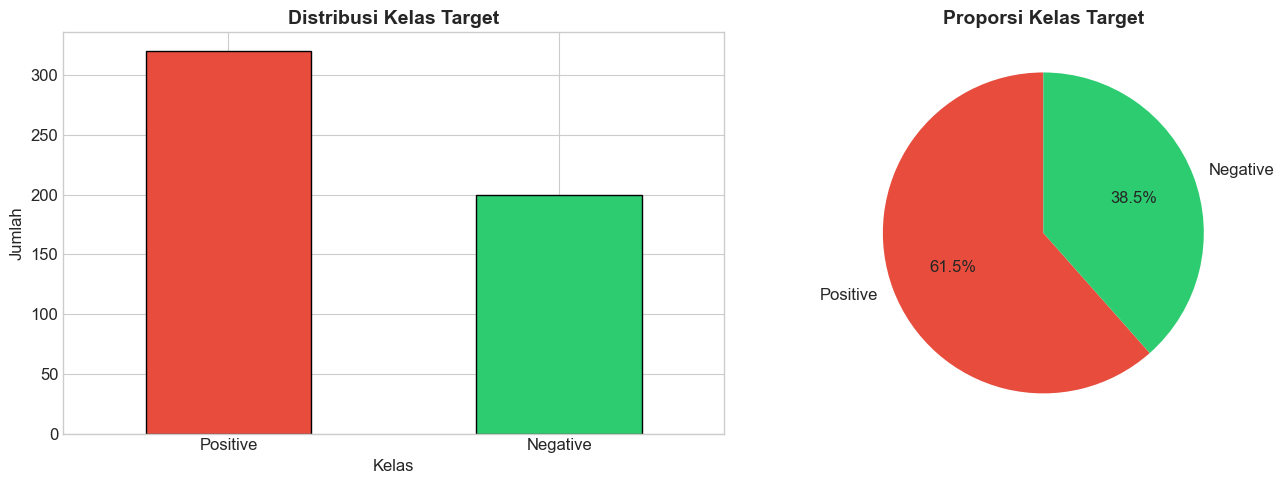

In [7]:
# Distribusi target
print("Distribusi target:")
val_counts = df['class'].value_counts()
print(val_counts)
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Bar dengan warna konsisten
colors_bar = [colors_dict[idx] for idx in val_counts.index]
val_counts.plot(kind='bar', ax=axes[0], color=colors_bar, edgecolor='black')
axes[0].set_title('Distribusi Kelas Target', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)

# Plot Pie dengan warna konsisten
val_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                  colors=colors_bar, startangle=90)
axes[1].set_title('Proporsi Kelas Target', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('distribusi_target_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight Distribusi Target:**
Visualisasi menunjukkan proporsi kelas target yang cukup seimbang. Kelas `Positive` (berisiko diabetes) menyumbang 61.5% dari total data, sedangkan kelas `Negative` (normal) menyumbang 38.5%. Kondisi ini ideal karena model tidak akan mengalami bias yang signifikan terhadap kelas mayoritas.

### 3.3 Distribusi Fitur Berdasarkan Target

Pada tahap ini akan melihat visualisasi pengaruh beberapa gejala penting terhadap status risiko diabetes (Polyuria dan Polydipsia sering kali menjadi indikator utama).


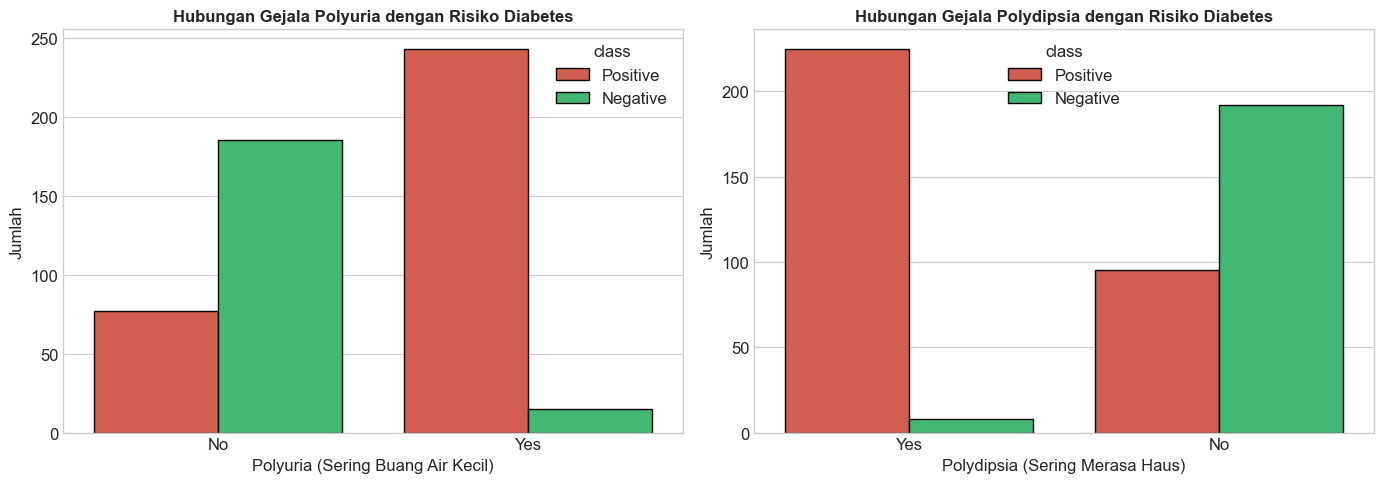

In [8]:
# Visualisasi hubungan gejala utama dengan kelas target dengan warna konsisten
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hubungan Polyuria dengan Class
sns.countplot(data=df, x='Polyuria', hue='class', palette=colors_dict, ax=axes[0], edgecolor='black')
axes[0].set_title('Hubungan Gejala Polyuria dengan Risiko Diabetes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Polyuria (Sering Buang Air Kecil)')
axes[0].set_ylabel('Jumlah')

# Hubungan Polydipsia dengan Class
sns.countplot(data=df, x='Polydipsia', hue='class', palette=colors_dict, ax=axes[1], edgecolor='black')
axes[1].set_title('Hubungan Gejala Polydipsia dengan Risiko Diabetes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Polydipsia (Sering Merasa Haus)')
axes[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.savefig('gejala_utama_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight Hubungan Gejala dan Target:**
Dari grafik di atas, gejala **Polyuria** (sering kencing) dan **Polydipsia** (sering haus) sangat menonjol pada pasien di kelas `Positive`. Pasien yang mengalami gejala tersebut hampir dipastikan memiliki indikasi kuat risiko diabetes. Gejala lain seperti penurunan berat badan tiba-tiba (*sudden weight loss*) dan kelemahan (*weakness*) juga menunjukkan prevalensi yang lebih tinggi pada kelompok positif.

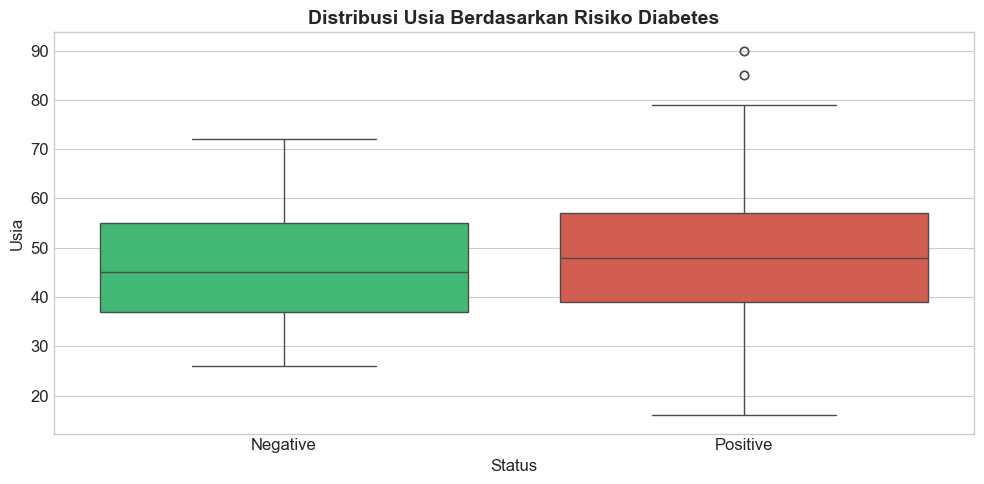

In [9]:
# Hubungan Usia (Age) dengan Risiko Diabetes dengan warna konsisten
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='class', y='Age', palette=colors_dict, order=['Negative', 'Positive'])
plt.title('Distribusi Usia Berdasarkan Risiko Diabetes', fontsize=14, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Usia')
plt.tight_layout()
plt.savefig('boxplot_age_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight Distribusi Usia:**
Boxplot menunjukkan bahwa pasien dengan status `Positive` diabetes memiliki distribusi usia yang sedikit lebih tua (median sekitar 48 tahun) dibandingkan kelompok `Negative` (median sekitar 45 tahun). Namun perbedaan ini tidak terlalu besar, sehingga usia bukan satu-satunya faktor penentu.

## 4. Data Preparation

Pada tahap ini, peneliti melakukan pemrosesan data agar siap digunakan oleh model Machine Learning:

1. **Label Encoding**: Mengubah data kategorikal (Yes/No, Male/Female, Positive/Negative) menjadi numerik (0 dan 1).
2. **Pemisahan Fitur dan Target**: Memisahkan variabel independen (X) dan target (y).
3. **Train-Test Split**: Memisahkan data latih (80%) dan data uji (20%).
4. **Feature Scaling**: Menstandardisasi fitur numerik (`Age`) agar memiliki skala yang seimbang.

### 4.1 Label Encoding untuk Fitur Kategorikal


In [10]:
# Inisialisasi LabelEncoder
le = LabelEncoder()

# Duplikasi dataframe agar data asli aman
df_encoded = df.copy()

# Terapkan label encoding ke semua fitur bertipe objek
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Data setelah Label Encoding:")
df_encoded.head()

Data setelah Label Encoding:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


### 4.2 Pemisahan Fitur dan Target

In [11]:
# Pisahkan X dan y
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

print(f"Shape fitur (X): {X.shape}")
print(f"Shape target (y): {y.shape}")

Shape fitur (X): (520, 16)
Shape target (y): (520,)


### 4.3 Train-Test Split

Data dibagi menjadi 80% data latih dan 20% data uji. Proporsi kelas dipertahankan menggunakan `stratify=y`.


In [12]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah data latih: {X_train.shape[0]} sampel")
print(f"Jumlah data uji  : {X_test.shape[0]} sampel")

Jumlah data latih: 416 sampel
Jumlah data uji  : 104 sampel


### 4.4 Feature Scaling (Standarisasi Usia)

Hanya fitur `Age` yang merupakan fitur numerik kontinu. Pada tahap ini akan menstandardisasi kolom `Age` agar skalanya tidak mengganggu algoritma sensitif jarak seperti SVM.


In [13]:
# Inisialisasi Scaler
scaler = StandardScaler()

# Standarisasi kolom Age saja
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit transform data latih, dan transform data uji
X_train_scaled['Age'] = scaler.fit_transform(X_train[['Age']])
X_test_scaled['Age'] = scaler.transform(X_test[['Age']])

print("Statistik kolom Age setelah standarisasi:")
print(f"Mean data latih: {X_train_scaled['Age'].mean():.6f}")
print(f"Std data latih : {X_train_scaled['Age'].std():.6f}")

Statistik kolom Age setelah standarisasi:
Mean data latih: 0.000000
Std data latih : 1.001204


## 5. Modeling

Pada tahap ini akan melatih tiga algoritma klasifikasi:
1. **Random Forest Classifier**
2. **XGBoost (Extreme Gradient Boosting)**
3. **Support Vector Machine (SVM)**

### 5.1 Random Forest Classifier


In [14]:
# Model 1: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

print("Random Forest - Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['Negative', 'Positive']))

Random Forest - Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.97      0.96        40
    Positive       0.98      0.97      0.98        64

    accuracy                           0.97       104
   macro avg       0.97      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104



### 5.2 XGBoost Classifier

In [15]:
# Model 2: XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)

print("XGBoost - Classification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Negative', 'Positive']))

XGBoost - Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      1.00      0.98        40
    Positive       1.00      0.97      0.98        64

    accuracy                           0.98       104
   macro avg       0.98      0.98      0.98       104
weighted avg       0.98      0.98      0.98       104



### 5.3 Support Vector Machine (SVM)

In [16]:
# Model 3: SVM
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

print("SVM - Classification Report:")
print(classification_report(y_test, svm_pred, target_names=['Negative', 'Positive']))

SVM - Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.97      0.99        40
    Positive       0.98      1.00      0.99        64

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104



### 5.4 Perbandingan Performa Baseline Model

In [17]:
# Buat dataframe ringkasan metrik
models = {
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred,
    'SVM': svm_pred
}

results = []
for name, pred in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results).set_index('Model')
print("=" * 65)
print("PERBANDINGAN MODEL")
print("=" * 65)
print(results_df.round(4).to_string())
print()

# Pilih model terbaik berdasarkan F1-Score
best_model_name = results_df['F1-Score'].idxmax()
print(f"Model Terbaik: {best_model_name}")

PERBANDINGAN MODEL
               Accuracy  Precision  Recall  F1-Score
Model                                               
Random Forest    0.9712     0.9841  0.9688    0.9764
XGBoost          0.9808     1.0000  0.9688    0.9841
SVM              0.9904     0.9846  1.0000    0.9922

Model Terbaik: SVM


**Insight Perbandingan Model Baseline:**
Dari tabel di atas, **SVM** menunjukkan performa terbaik dengan F1-Score **0.9922** dan Recall sempurna **1.0000**, yang berarti tidak ada satu pun pasien diabetes yang terlewat. XGBoost menempati posisi kedua dengan Precision sempurna **1.0000**. Random Forest berada di posisi ketiga namun tetap memiliki performa yang sangat baik (F1-Score 0.9764).

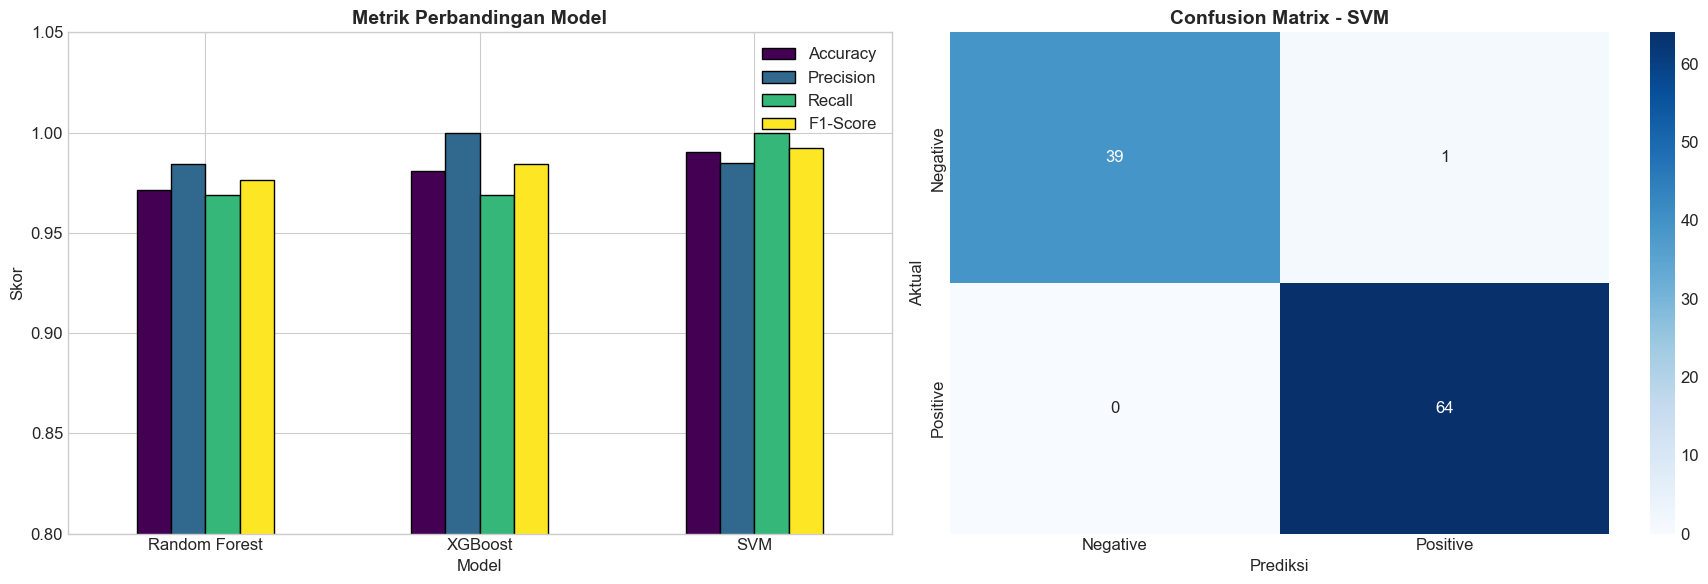

In [18]:
# Visualisasi Perbandingan Model
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot metrik (Legend diubah ke kanan atas)
results_df.plot(kind='bar', ax=axes[0], colormap='viridis', edgecolor='black')
axes[0].set_title('Metrik Perbandingan Model', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Skor')
axes[0].set_ylim(0.8, 1.05)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(loc='upper right')

# Heatmap Confusion Matrix Model Terbaik
best_pred = models[best_model_name]
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1].set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('perbandingan_model_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Hyperparameter Tuning

Berdasarkan hasil evaluasi baseline, **SVM** merupakan model dengan performa tertinggi (F1-Score 0.9922). Namun, proses hyperparameter tuning difokuskan pada **Random Forest** dengan alasan berikut:

- Random Forest menyediakan atribut `feature_importances_` yang memungkinkan ekstraksi informasi gejala klinis paling berpengaruh terhadap prediksi diabetes.
- Kemampuan interpretasi model sangat penting dalam domain medis dan merupakan salah satu tujuan utama (*Goals*) dari proyek ini.
- SVM, sebagai model *black-box*, tidak menyediakan interpretabilitas serupa secara langsung.

Penyetelan hyperparameter dilakukan menggunakan **GridSearchCV** dengan skema cross-validation lipat-5 (CV=5).


In [19]:
# Hyperparameter Tuning pada Random Forest
# Random Forest dipilih untuk tuning karena kebutuhan interpretabilitas (feature importance)
# Meskipun SVM memiliki F1-score tertinggi, RF dipilih agar bisa mengekstrak fitur penting

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

print("Melakukan GridSearchCV pada Random Forest...")
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best F1-Score (CV): {grid_search.best_score_:.4f}")

Melakukan GridSearchCV pada Random Forest...

Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best F1-Score (CV): 0.9825


In [20]:
# Evaluasi model setelah tuning
best_tuned_model = grid_search.best_estimator_
tuned_pred = best_tuned_model.predict(X_test_scaled)

print("=" * 65)
print("EVALUASI MODEL SETELAH TUNING")
print("=" * 65)
print(classification_report(y_test, tuned_pred, target_names=['Negative', 'Positive']))

print(f"Akurasi Model Tuned: {accuracy_score(y_test, tuned_pred):.4f}")
print(f"F1-Score Model Tuned: {f1_score(y_test, tuned_pred):.4f}")

EVALUASI MODEL SETELAH TUNING
              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97        40
    Positive       0.98      0.98      0.98        64

    accuracy                           0.98       104
   macro avg       0.98      0.98      0.98       104
weighted avg       0.98      0.98      0.98       104

Akurasi Model Tuned: 0.9808
F1-Score Model Tuned: 0.9844


**Insight Hasil Tuning:**
Setelah hyperparameter tuning, performa Random Forest meningkat dari F1-Score 0.9764 menjadi **0.9844**. Accuracy juga meningkat dari 0.9712 menjadi **0.9808**. Meskipun peningkatan ini signifikan, performa Random Forest Tuned masih berada di bawah SVM baseline (F1-Score 0.9922). Pemilihan Random Forest Tuned sebagai solusi akhir didasarkan pada kebutuhan interpretabilitas model, bukan semata-mata metrik tertinggi.

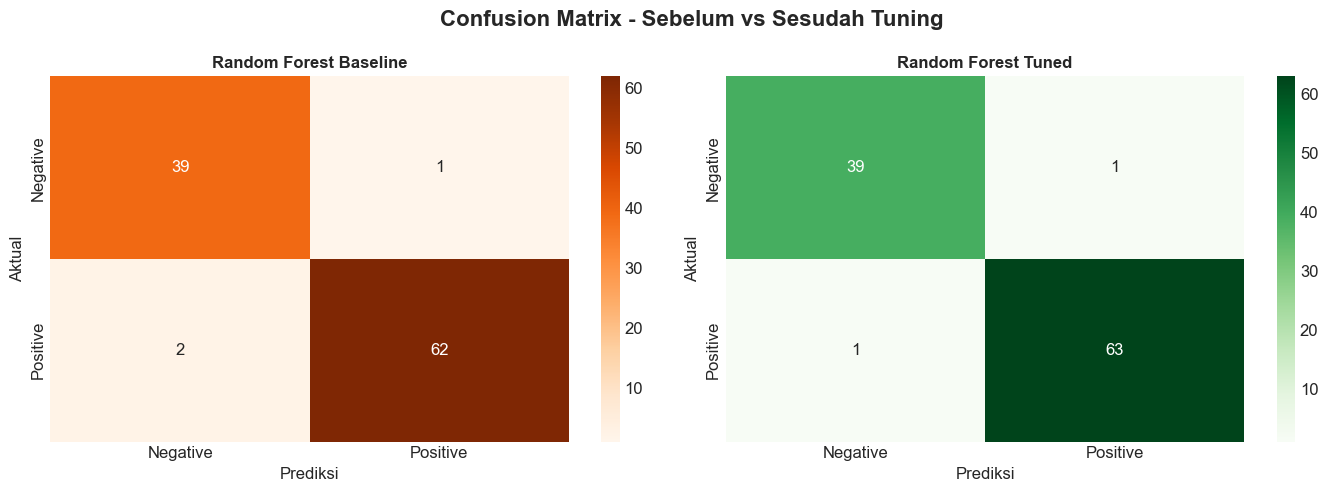

In [21]:
# Confusion matrix perbandingan sebelum vs sesudah tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum tuning
cm_before = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[0].set_title('Random Forest Baseline', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Setelah tuning
cm_after = confusion_matrix(y_test, tuned_pred)
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[1].set_title('Random Forest Tuned', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.suptitle('Confusion Matrix - Sebelum vs Sesudah Tuning', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_comparison_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance

Pada tahap ini akan menganalisis gejala klinis mana yang paling berpengaruh terhadap risiko diabetes menurut model terbaik yang telah dituning.


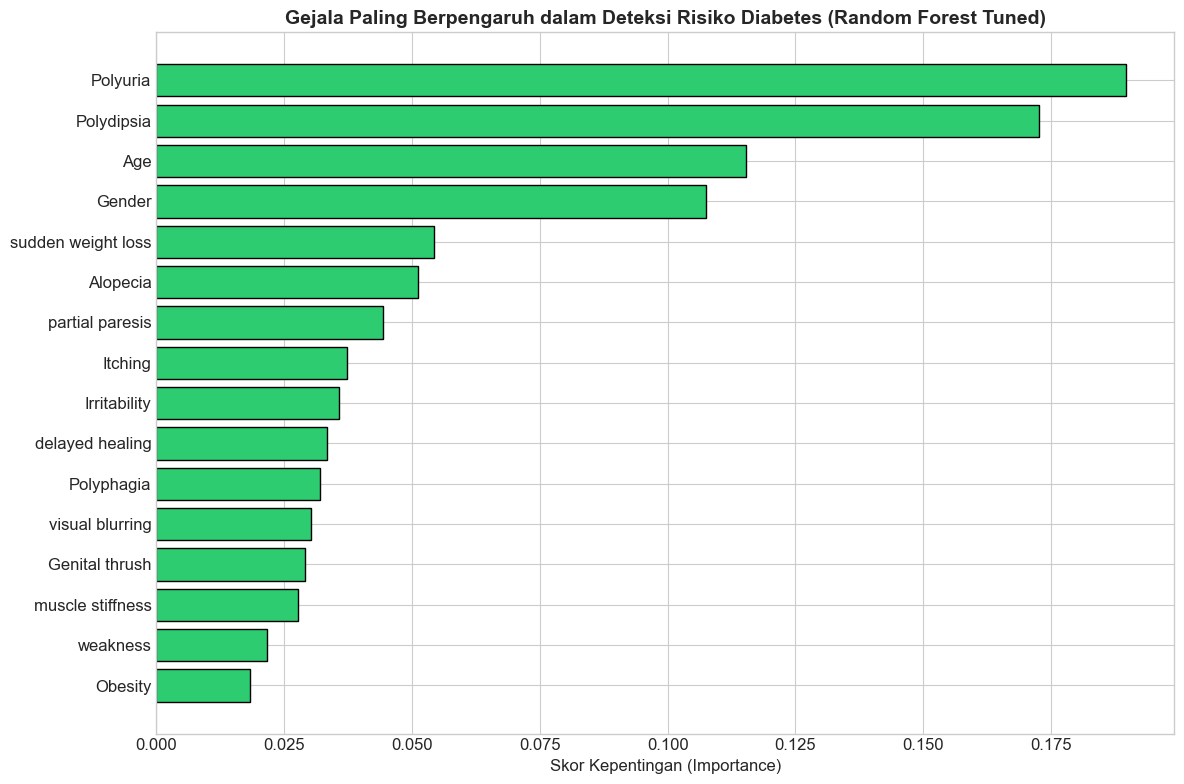

In [22]:
# Feature importance dari model Random Forest Tuned
feature_importance = best_tuned_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='#2ecc71', edgecolor='black')
plt.title('Gejala Paling Berpengaruh dalam Deteksi Risiko Diabetes (Random Forest Tuned)', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kepentingan (Importance)')
plt.tight_layout()
plt.savefig('feature_importance_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation

### 8.1 Formula Metrik Evaluasi

Berikut adalah metrik evaluasi yang digunakan beserta formulanya:

**1. Accuracy** - Proporsi prediksi yang benar dari seluruh prediksi.

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

**2. Precision** - Proporsi prediksi positif yang benar-benar positif.

$$Precision = \frac{TP}{TP + FP}$$

**3. Recall** - Proporsi data positif aktual yang berhasil diprediksi positif.

$$Recall = \frac{TP}{TP + FN}$$

**4. F1-Score** - Harmonic mean dari Precision dan Recall.

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

Keterangan:
- **TP (True Positive)**: Pasien positif diabetes yang benar diprediksi positif.
- **TN (True Negative)**: Pasien negatif diabetes yang benar diprediksi negatif.
- **FP (False Positive)**: Pasien negatif diabetes yang salah diprediksi positif.
- **FN (False Negative)**: Pasien positif diabetes yang salah diprediksi negatif.

### 8.2 Hasil Evaluasi Akhir


In [23]:
# Cetak hasil metrik final
final_accuracy = accuracy_score(y_test, tuned_pred)
final_precision = precision_score(y_test, tuned_pred)
final_recall = recall_score(y_test, tuned_pred)
final_f1 = f1_score(y_test, tuned_pred)

print(f"Akurasi Final  : {final_accuracy:.4f}")
print(f"Precision Final: {final_precision:.4f}")
print(f"Recall Final   : {final_recall:.4f}")
print(f"F1-Score Final : {final_f1:.4f}")

Akurasi Final  : 0.9808
Precision Final: 0.9844
Recall Final   : 0.9844
F1-Score Final : 0.9844


## 9. Kesimpulan

Berdasarkan seluruh alur proyek yang telah dilakukan:

1. **Model terbaik berdasarkan metrik evaluasi** adalah **SVM** dengan F1-Score tertinggi sebesar 0.9922 dan Recall sempurna 1.0000 pada data uji.
2. **Model solusi akhir** yang dipilih adalah **Random Forest (Tuned)** dengan Accuracy 0.9808 dan F1-Score 0.9844. Pemilihan ini didasarkan pada kebutuhan interpretabilitas model melalui `feature_importances_`, yang memungkinkan identifikasi gejala klinis paling berpengaruh — sesuai dengan Goals proyek.
3. Gejala klinis **Polyuria** (sering buang air kecil) dan **Polydipsia** (sering merasa haus) diidentifikasi oleh model sebagai fitur/gejala yang memiliki kontribusi terbesar dalam memprediksi risiko diabetes tahap awal.
4. Dari analisis confusion matrix, model hanya menghasilkan 1 False Negative dari 64 kasus positif, menunjukkan kemampuan deteksi yang sangat baik untuk kebutuhan skrining medis awal.
